#  Customer Segmentation Using Unsupervised Learning

##  Problem Statement

Online retail businesses generate a large amount of customer transaction data. However, raw transaction records do not directly reveal customer purchasing behavior or indicate which customers are high-value, inactive, or require different marketing strategies.

The objective of this project is to analyze historical retail transaction data and identify meaningful customer segments based on their purchasing behavior using **Recency, Frequency, and Monetary (RFM) Analysis** and **Unsupervised Machine Learning**.

The project will use **K-Means Clustering** to group customers with similar purchasing patterns and convert these clusters into actionable business segments. These insights can help the business improve customer retention, personalized marketing, loyalty programs, and customer reactivation strategies.

---

##  Project Objectives

- Clean and prepare the raw retail transaction data.
- Perform exploratory data analysis to understand customer and transaction behavior.
- Calculate **Recency, Frequency, and Monetary (RFM)** features for each customer.
- Analyze and handle skewness in the RFM features.
- Apply **Log Transformation** where required.
- Standardize the features using **StandardScaler**.
- Build a professional **Scikit-Learn Pipeline** for preprocessing and clustering.
- Determine an appropriate number of customer segments using the **Elbow Method** and **Silhouette Score**.
- Apply **K-Means Clustering** to segment customers.
- Evaluate other clustering approaches such as **Hierarchical Clustering** and **DBSCAN**.
- Profile and interpret the identified customer segments.
- Generate actionable business insights and recommendations.

---

##  Business Question

> **How can an online retail business use historical customer transaction data to identify meaningful customer segments and develop targeted strategies for each customer group?**

---

##  Expected Outcome

The project aims to transform raw transactional data into meaningful customer segments that can help the business identify:

- 🔴 **Inactive / Lost Customers**
- 🟢 **High-Value / Loyal Customers**
- 🔵 **Regular / Low-Value Customers**

These segments can then be used to develop targeted **retention, reactivation, loyalty, personalization, and marketing strategies**.

In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
import os
filterwarnings('ignore')

In [222]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)



Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Path to dataset files: /kaggle/input/online-retail-ii-uci


In [223]:
print(os.listdir(path))

['online_retail_II.csv']


In [224]:
filepath = os.path.join(path, 'online_retail_II.csv')
data = pd.read_csv(filepath)

In [225]:
df = data.copy()

In [226]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [227]:
df.shape

(1067371, 8)

In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [229]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [230]:
df.duplicated().sum()

np.int64(34335)

In [231]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,15324.638504,1697.464450,12346.00,13975.00,15255.0,16797.00,18287.0


In [232]:
df.describe(include=[object]).T

,count,unique,top,freq
Invoice,1067371,53628,537434,1350
StockCode,1067371,5305,85123A,5829
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918
InvoiceDate,1067371,47635,2010-12-06 16:57:00,1350
Country,1067371,43,United Kingdom,981330


In [233]:
df['Customer ID'].nunique()

5942

In [234]:
df['Country'].nunique()

43

In [235]:
(df['Quantity'] < 0).sum()

np.int64(22950)

In [236]:
(df['Price'] < 0).sum()

np.int64(5)

In [237]:
(df['Price'] == 0).sum()

np.int64(6202)

In [238]:
df['Invoice'].astype(str).str.startswith('C').sum()

np.int64(19494)

In [239]:
df[df["Invoice"].astype(str).str.startswith("C")].head(25)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [240]:
df[df["Customer ID"].isna()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [241]:
df_clean = df.dropna(subset=['Customer ID']).copy()

In [242]:
df_clean.shape

(824364, 8)

In [243]:
df_clean['Quantity'].min()

-80995

In [244]:
(df_clean['Quantity'] < 0).sum()

np.int64(18744)

In [245]:
df_clean[df_clean["Quantity"] < 0]["Invoice"].astype(str).str.startswith("C").sum()

np.int64(18744)

In [246]:
df_clean = df_clean[df_clean["Quantity"] > 0].copy()

In [247]:
df_clean[df_clean["Price"] < 0]["Invoice"].astype(str).str.startswith("C").sum()

np.int64(0)

In [248]:
(df_clean["Price"] == 0).sum()

np.int64(71)

In [249]:

df_clean[df_clean["Price"] == 0].head(25)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom


In [250]:
df_clean = df_clean[df_clean["Price"] > 0].copy()

In [251]:
df_clean.duplicated().sum()

np.int64(26124)

In [252]:
df_clean = df_clean.drop_duplicates().copy()

In [253]:
df_clean.shape

(779425, 8)

In [254]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

In [255]:
df_clean["Revenue"]

,Revenue
0,83.40
1,81.00
2,81.00
3,100.80
4,30.00
...,...
1067366,12.60
1067367,16.60
1067368,16.60
1067369,14.85


In [256]:
df_clean[["Quantity","Price","Revenue"]].head(5)

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [257]:
customer_revenue = df_clean.groupby("Customer ID")["Revenue"].sum()

In [258]:
customer_revenue.head()

,Revenue
Customer ID,
12346.0,77556.46
12347.0,4921.53
12348.0,2019.40
12349.0,4428.69
12350.0,334.40


In [259]:
customer_frequency = df_clean.groupby("Customer ID")["Invoice"].nunique()

In [260]:
customer_frequency.head()

,Invoice
Customer ID,
12346.0,12
12347.0,8
12348.0,5
12349.0,4
12350.0,1


In [261]:
customer_last_purchase = df_clean.groupby("Customer ID")["InvoiceDate"].max()

In [262]:
customer_last_purchase.head()

,InvoiceDate
Customer ID,
12346.0,2011-01-18 10:01:00
12347.0,2011-12-07 15:52:00
12348.0,2011-09-25 13:13:00
12349.0,2011-11-21 09:51:00
12350.0,2011-02-02 16:01:00


In [263]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [264]:
customer_last_purchase = df_clean.groupby("Customer ID")["InvoiceDate"].max()

In [265]:
customer_last_purchase.head()

,InvoiceDate
Customer ID,
12346.0,2011-01-18 10:01:00
12347.0,2011-12-07 15:52:00
12348.0,2011-09-25 13:13:00
12349.0,2011-11-21 09:51:00
12350.0,2011-02-02 16:01:00


In [266]:
reference_date = df_clean["InvoiceDate"].max() + pd.DateOffset(days=1)

In [267]:
reference_date

Timestamp('2011-12-10 12:50:00')

In [268]:
customer_recency = (reference_date - customer_last_purchase).dt.days

In [269]:
customer_recency.head()

,InvoiceDate
Customer ID,
12346.0,326
12347.0,2
12348.0,75
12349.0,19
12350.0,310


In [270]:
rfm = pd.concat([customer_recency,customer_frequency,customer_revenue],axis=1)

In [271]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [272]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [273]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [274]:
rfm.skew()

,0
Recency,0.887198
Frequency,12.639951
Monetary,25.070190


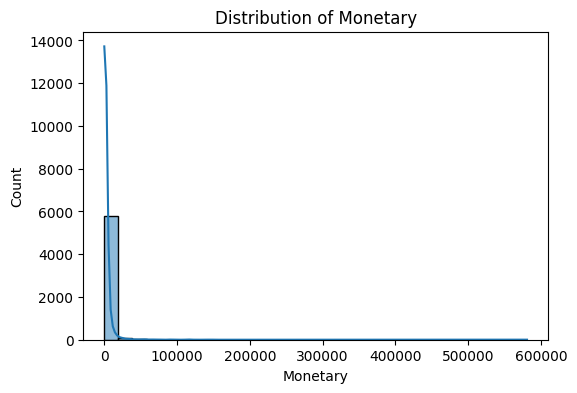

In [275]:
plt.figure(figsize=(6,4))
sns.histplot(rfm['Monetary'],bins=30,kde=True)
plt.title('Distribution of Monetary')
plt.show()

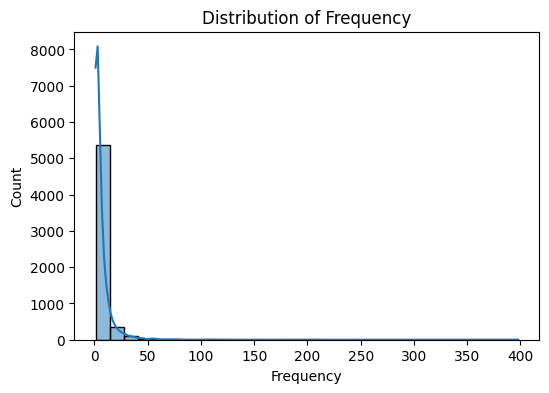

In [276]:
plt.figure(figsize=(6,4))
sns.histplot(rfm['Frequency'],bins=30,kde=True)
plt.title('Distribution of Frequency')
plt.show()

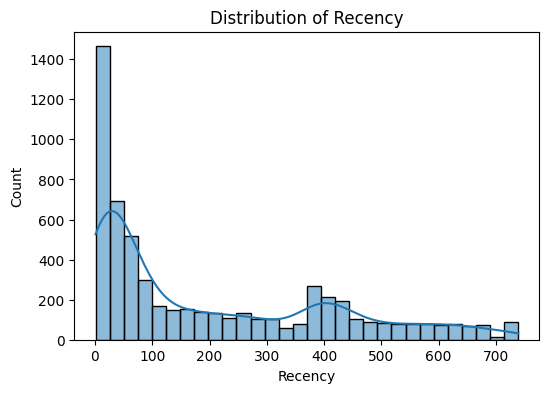

In [277]:
plt.figure(figsize=(6,4))
sns.histplot(rfm['Recency'],bins=30,kde=True)
plt.title('Distribution of Recency')
plt.show()

In [278]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans

In [279]:

preprocessor = ColumnTransformer(transformers=[
        ("log", FunctionTransformer(np.log1p), ["Frequency", "Monetary"])
    ],
    remainder="passthrough"
)

kmeans_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(
            n_clusters=4,
            random_state=42,
            n_init=10
        ))
    ]
)

In [280]:
kmeans_pipeline.fit(rfm)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['Frequency', 'Monetary'])])),
                ('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=4, n_init=10, random_state=42))])

In [282]:
inertia = []
for k in range(1,11):
  pipeline = Pipeline(steps = [
      ("preprocessor" ,preprocessor),
      ("scaler",StandardScaler()),
      ("kmeans",KMeans(n_clusters=k,random_state=42,n_init=10))
  ])

  pipeline.fit(rfm)
  inertia.append(pipeline.named_steps["kmeans"].inertia_)

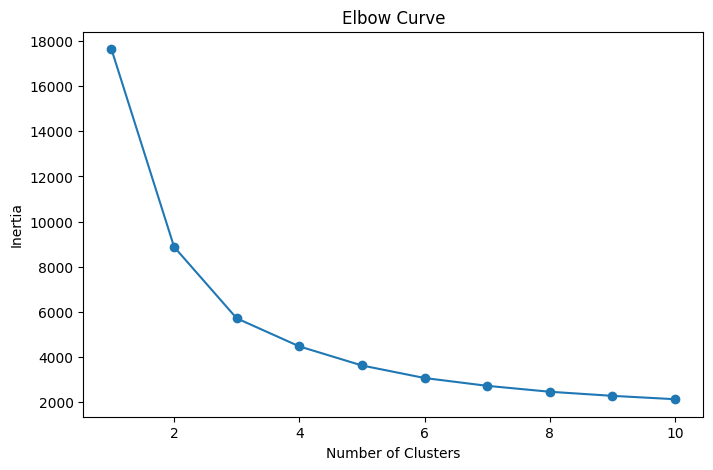

In [284]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),inertia,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.show()

In [285]:
from sklearn.metrics import silhouette_score

In [286]:
silhouette_scores = []

X_prepared = preprocessor.fit_transform(rfm)
X_scaled = StandardScaler().fit_transform(X_prepared)

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

In [287]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K={k}: {score:.4f}")

K=2: 0.4187
K=3: 0.4010
K=4: 0.3616
K=5: 0.3664
K=6: 0.3469
K=7: 0.3353
K=8: 0.3155
K=9: 0.3093
K=10: 0.2954


In [288]:
kmeans_3 = KMeans(n_clusters=3,random_state=42,n_init=10)

labels_3 = kmeans_3.fit_predict(X_scaled)

In [289]:
pd.Series(labels_3).value_counts().sort_index()

,count
0,1840
1,1675
2,2363


In [290]:
kmeans_pipeline.set_params(kmeans__n_clusters=3)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['Frequency', 'Monetary'])])),
                ('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, n_init=10, random_state=42))])

In [291]:
kmeans_pipeline.fit(rfm)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['Frequency', 'Monetary'])])),
                ('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, n_init=10, random_state=42))])

In [292]:
rfm["Cluster"] = kmeans_pipeline.predict(rfm)

In [293]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

In [294]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,472.945652,1.788587,555.300958
1,57.290746,15.953433,8561.950574
2,91.936945,2.943716,851.368301


In [295]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean")
).round(2)

In [296]:
cluster_summary

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,1840,472.95,1.79,555.30
1,1675,57.29,15.95,8561.95
2,2363,91.94,2.94,851.37


In [297]:
cluster_names = {
    0: "Inactive / Lost",
    1: "High-Value / Loyal",
    2: "Regular / Low-Value"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

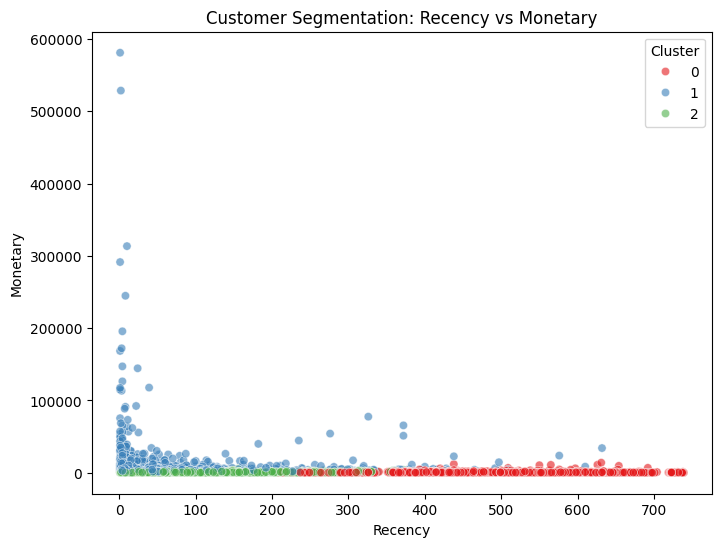

In [302]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set1",
    alpha=0.6
)

plt.title("Customer Segmentation: Recency vs Monetary")
plt.show()

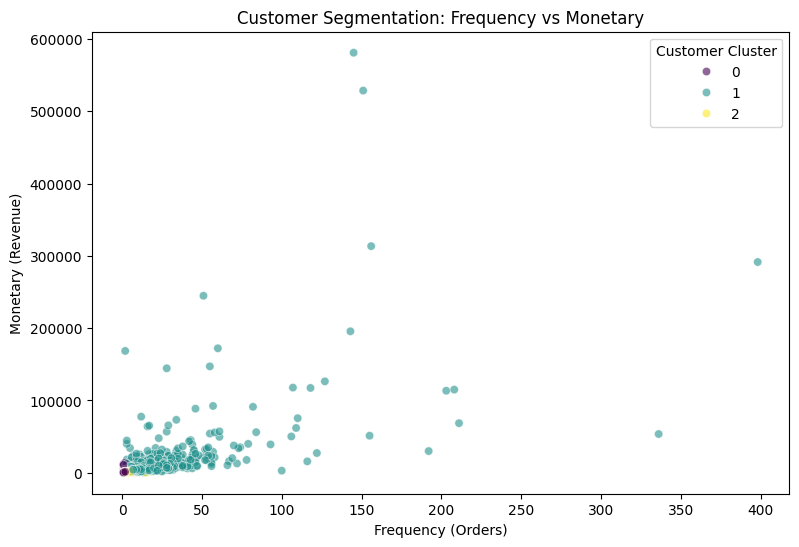

In [312]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    alpha=0.6
)

plt.title("Customer Segmentation: Frequency vs Monetary")
plt.xlabel("Frequency (Orders)")
plt.ylabel("Monetary (Revenue)")
plt.legend(title="Customer Cluster")
plt.show()

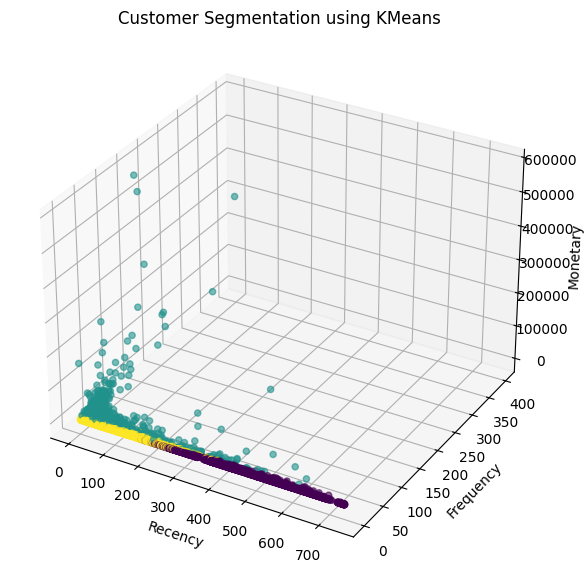

In [321]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis",
    alpha=0.6
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

ax.set_title("Customer Segmentation using KMeans")

plt.show()

In [322]:
import joblib

joblib.dump(kmeans_pipeline,"customer_segmentation_pipeline.pkl")

['customer_segmentation_pipeline.pkl']

#  Conclusion

This project successfully analyzed customer purchasing behavior using historical online retail transaction data and applied **RFM Analysis** with **Unsupervised Machine Learning** to identify meaningful customer segments.

The raw transaction data was cleaned and transformed into customer-level **Recency, Frequency, and Monetary (RFM)** features. Since Frequency and Monetary showed significant right-skewness, appropriate log transformations were applied, followed by feature scaling using a **Scikit-Learn Pipeline**.

Different clustering approaches were evaluated, including **K-Means, Hierarchical Clustering, and DBSCAN**. Based on cluster separation, evaluation metrics, and business interpretability, **K-Means with 3 clusters** was selected as the final segmentation approach, achieving a **Silhouette Score of 0.4010**.

The final model identified three meaningful customer segments:

| Customer Segment | Customer Behavior |
|---|---|
| 🔴 **Inactive / Lost** | Customers with high recency, low purchase frequency, and low spending |
| 🟢 **High-Value / Loyal** | Customers with recent purchases, high purchase frequency, and high spending |
| 🔵 **Regular / Low-Value** | Customers with moderate recency and relatively low purchase frequency and spending |

These segments provide actionable insights for the business. **High-value customers** can be targeted with loyalty programs and exclusive offers, **inactive customers** can be approached through reactivation and retention campaigns, while **regular customers** can be encouraged to increase their purchase frequency through personalized recommendations, cross-selling, and targeted promotions.

Overall, this project demonstrates how **unsupervised learning can transform raw transactional data into meaningful customer insights and support data-driven marketing and customer retention strategies.**